In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [8]:
df = pd.read_csv(r"C:\Users\anits-csm\Desktop\ML CSM-B 83\house-price.csv")

In [9]:
print(df.shape)

print(df.info())

print(df.describe())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000

In [10]:
le = LabelEncoder()

df["mainroad"] = le.fit_transform(df["mainroad"])

df["guestroom"] = le.fit_transform(df["guestroom"])

df["basement"] = le.fit_transform(df["basement"])

df["hotwaterheating"] = le.fit_transform(df["hotwaterheating"])

df["airconditioning"] = le.fit_transform(df["airconditioning"])

df["prefarea"] = le.fit_transform(df["prefarea"])

df["furnishingstatus"] = le.fit_transform(df["furnishingstatus"])

In [11]:
X = df.drop("price", axis=1)

y = df["price"]

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
cov_matrix = np.cov(X_scaled.T)

print(cov_matrix)

[[ 1.00183824  0.15213764  0.19417582  0.08415046  0.28940513  0.14055449
   0.04750415 -0.0092462   0.22280191  0.35362934  0.23521038 -0.17176052]
 [ 0.15213764  1.00183824  0.37461761  0.40931527 -0.01205536  0.08069677
   0.09749131  0.04613354  0.16089848  0.13952591  0.07916833 -0.12347055]
 [ 0.19417582  0.37461761  1.00183824  0.32676427  0.04247556  0.12670132
   0.1022934   0.06728255  0.18725862  0.1778221   0.06358842 -0.14382339]
 [ 0.08415046  0.40931527  0.32676427  1.00183824  0.12192986  0.0436177
  -0.17271052  0.01888116  0.29414171  0.04563082  0.04450654 -0.10486475]
 [ 0.28940513 -0.01205536  0.04247556  0.12192986  1.00183824  0.09250666
   0.04408297 -0.01180315  0.10561679  0.20480834  0.2002432  -0.15701396]
 [ 0.14055449  0.08069677  0.12670132  0.0436177   0.09250666  1.00183824
   0.37274965 -0.01032683  0.13843277  0.03753462  0.1611927  -0.11854508]
 [ 0.04750415  0.09749131  0.1022934  -0.17271052  0.04408297  0.37274965
   1.00183824  0.0043929   0.0474

In [14]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

sorted_idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_idx]

eigen_vectors = eigen_vectors[:, sorted_idx]

In [15]:
k = 2

projection_matrix = eigen_vectors[:, :k]

X_pca = X_scaled.dot(projection_matrix)

In [16]:
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("Explained Variance Ratio:")

print(explained_variance_ratio)

print()

print("Cumulative Variance (2 PCs):")

print(np.sum(explained_variance_ratio[:2]))

Explained Variance Ratio:
[0.20622765 0.1278482  0.10650708 0.09434955 0.07455508 0.07314426
 0.06737316 0.0615989  0.05378615 0.05224405 0.04777492 0.03459102]

Cumulative Variance (2 PCs):
0.33407584644302973


In [17]:
pca = PCA(n_components=2)

X_pca_sklearn = pca.fit_transform(X_scaled)

print("Explained Variance Ratio using Scikit-Learn:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio using Scikit-Learn:
[0.20622765 0.1278482 ]


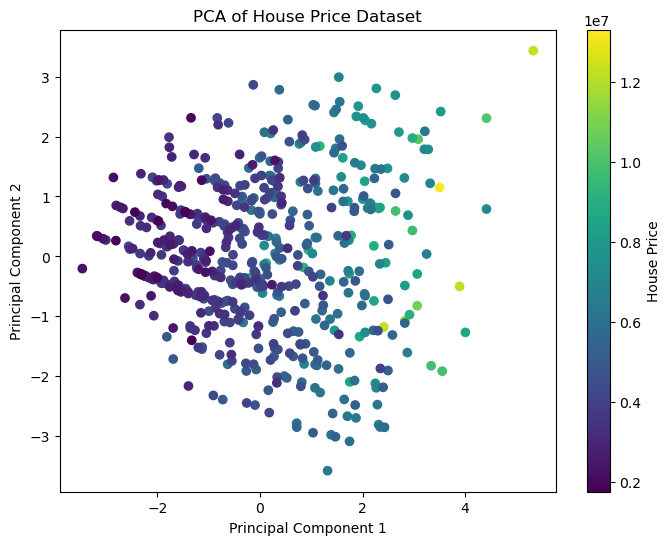

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_sklearn[:,0],
    X_pca_sklearn[:,1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA of House Price Dataset")

plt.colorbar(label="House Price")

plt.show()